In [2]:
import numpy as np
import pandas as pd
import io
import os
import matplotlib.pyplot as plt

In [30]:
def load_training_log(log_file="training_log.csv"):
    models = {}
    with open(log_file, "r") as f:
        content = f.read()

    for block in content.strip().split("\n\n"):
        lines = block.strip().split("\n")
        if len(lines) < 3:  # skip empty or malformed blocks
            continue
        name        = lines[0]
        description = lines[1]
        csv_data    = "\n".join(lines[2:])
        df          = pd.read_csv(io.StringIO(csv_data))
        models[name] = {"description": description, "history": df}

    return models

In [41]:
print("Model descriptions:")
models = load_training_log('output_logs_and_models/training_log.csv')
print(models['full_model_2']['history']['val_mAP'])

Model descriptions:
0     0.1523
1     0.2072
2     0.2344
3     0.2495
4     0.2711
       ...  
95    0.4006
96    0.4023
97    0.4027
98    0.4014
99    0.4006
Name: val_mAP, Length: 100, dtype: float64


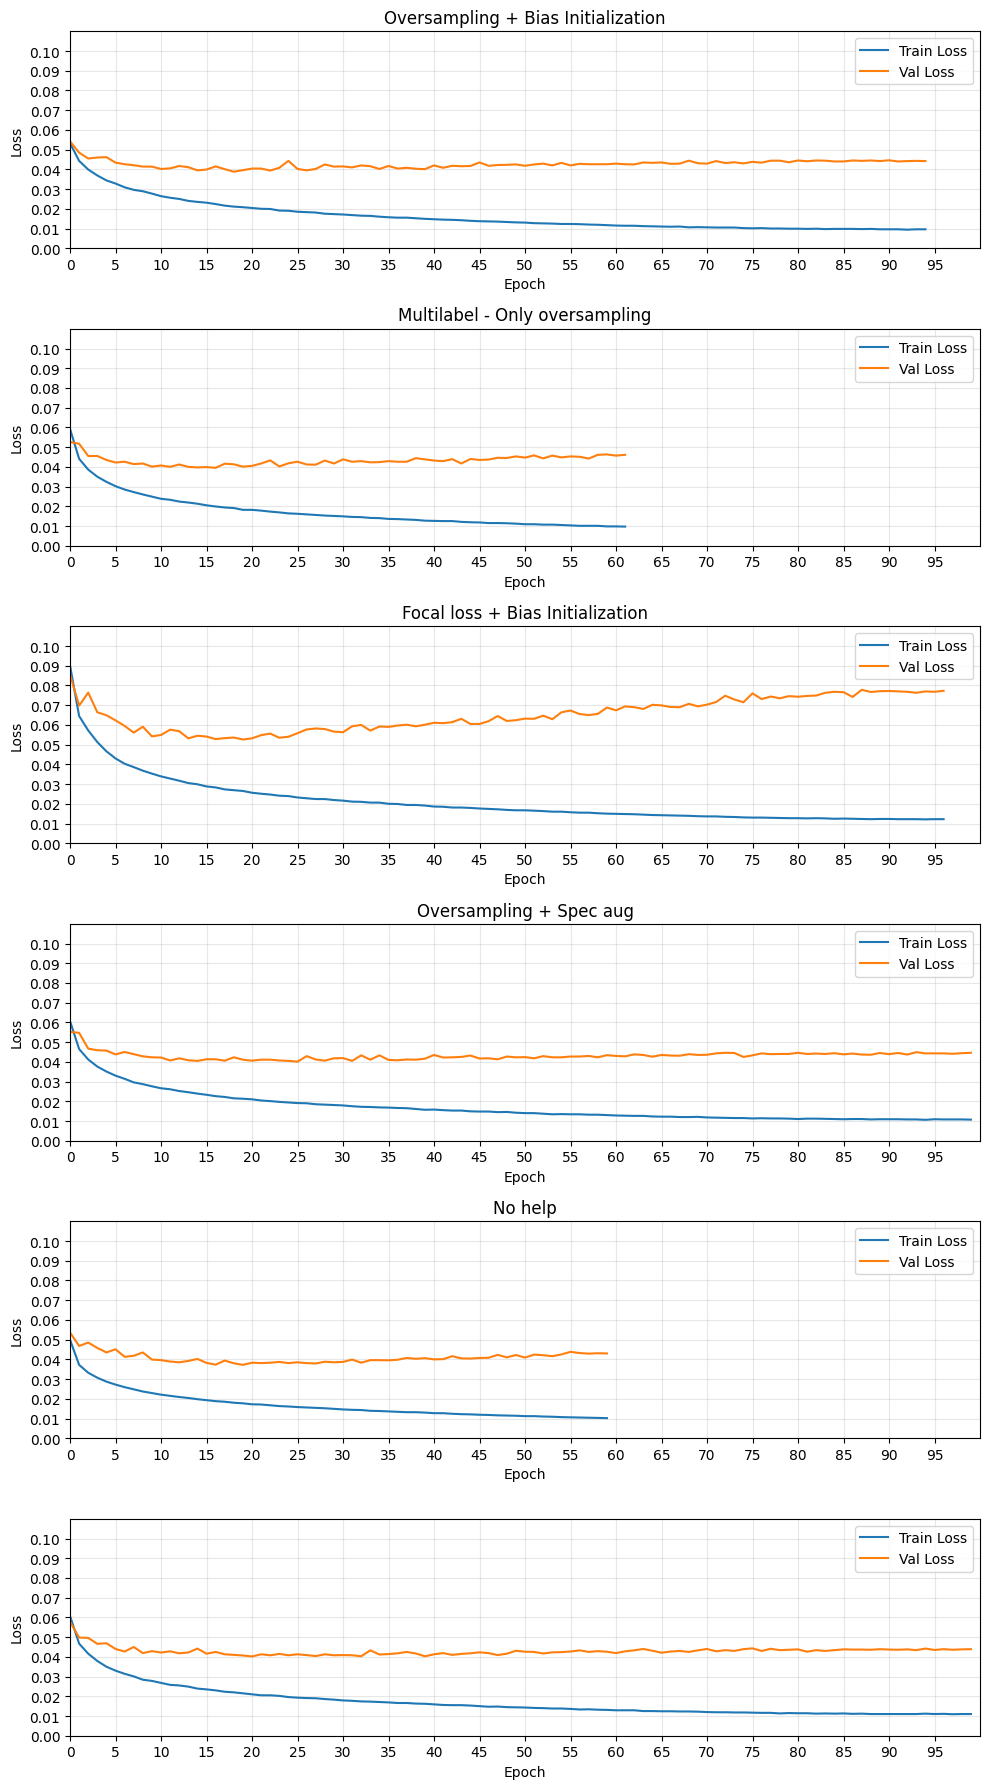

In [18]:
models = load_training_log("output_logs_and_models/training_log.csv")
train_loss = []
val_loss   = []
val_mAP    = []

for name, model in list(models.items())[6:]:
    train_loss.append(model["history"]["train_loss"])
    val_loss.append(model["history"]["val_loss"])
    val_mAP.append(model["history"]["val_mAP"])


fig, axs = plt.subplots(len(models.items())-6, 1, figsize=(10, 3*(len(models.items())-6)))
for i, (name, model) in enumerate(list(models.items())[6:]):
    axs[i].plot(train_loss[i], label="Train Loss")
    axs[i].plot(val_loss[i], label="Val Loss")

for ax in axs:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_ylim(0, 0.11)
    ax.set_xlim(0, len(train_loss[i]))
    ax.set_yticks(np.arange(0, 0.11, 0.01))
    ax.set_xticks(np.arange(0, len(train_loss[i]), 5))
    ax.grid(alpha=0.3)
    ax.legend()

axs[0].set_title("Oversampling + Bias Initialization")
axs[1].set_title("Multilabel - Only oversampling")
axs[2].set_title("Focal loss + Bias Initialization")
axs[3].set_title("Oversampling + Spec aug")
axs[4].set_title("No help")

plt.tight_layout()
plt.show()

In [42]:
#models
oversampling_only_valmap = models['full_model_9']['history']['val_mAP']
focal_loss_bias_init = models['full_model_10']['history']['val_mAP']
baseline = models['full_model_12']['history']['val_mAP']
oversampling_specaug_mixup = models['full_model_13']['history']['val_mAP']

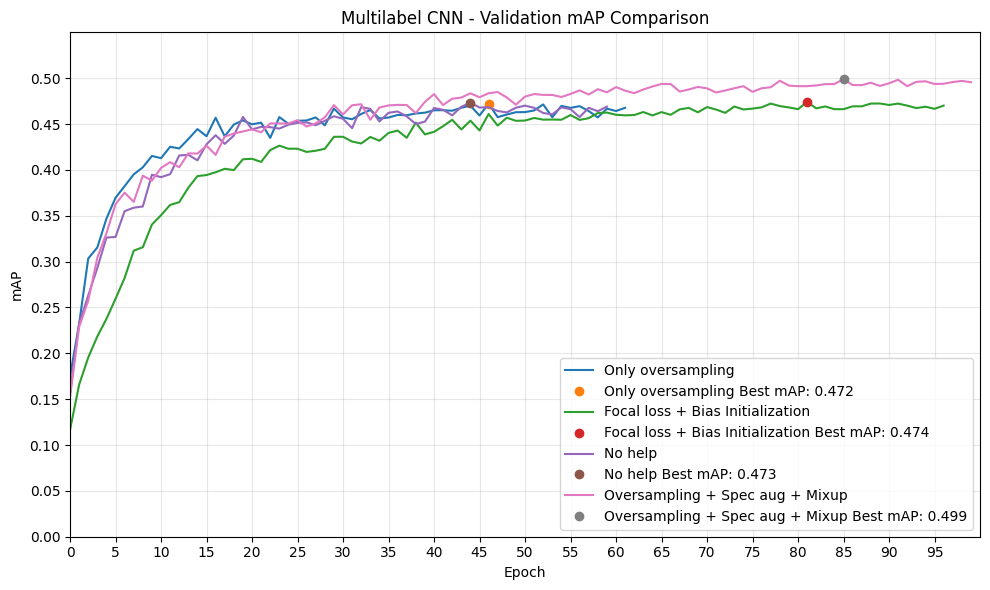

In [51]:
fig, axs = plt.subplots(1, 1, figsize=(10, 6))
axs.plot(oversampling_only_valmap, label="Only oversampling")
axs.plot(oversampling_only_valmap.idxmax(), oversampling_only_valmap.max(), "o", label=f"Only oversampling Best mAP: {oversampling_only_valmap.max():.3f}")
axs.plot(focal_loss_bias_init, label="Focal loss + Bias Initialization")
axs.plot(focal_loss_bias_init.idxmax(), focal_loss_bias_init.max(), "o", label=f"Focal loss + Bias Initialization Best mAP: {focal_loss_bias_init.max():.3f}")
axs.plot(baseline, label="No help")
axs.plot(baseline.idxmax(), baseline.max(), "o", label=f"No help Best mAP: {baseline.max():.3f}")
axs.plot(oversampling_specaug_mixup, label="Oversampling + Spec aug + Mixup")
axs.plot(oversampling_specaug_mixup.idxmax(), oversampling_specaug_mixup.max(), "o", label=f"Oversampling + Spec aug + Mixup Best mAP: {oversampling_specaug_mixup.max():.3f}")

axs.set_title("Multilabel CNN - Validation mAP Comparison")
axs.set_xlabel("Epoch")
axs.set_ylabel("mAP")
axs.set_ylim(0, 0.55)
axs.set_xlim(0, 100)
axs.set_yticks(np.arange(0, 0.55, 0.05))
axs.set_xticks(np.arange(0, 100, 5))
axs.grid(alpha=0.3)
axs.legend(loc="lower right")

plt.tight_layout()
plt.show()

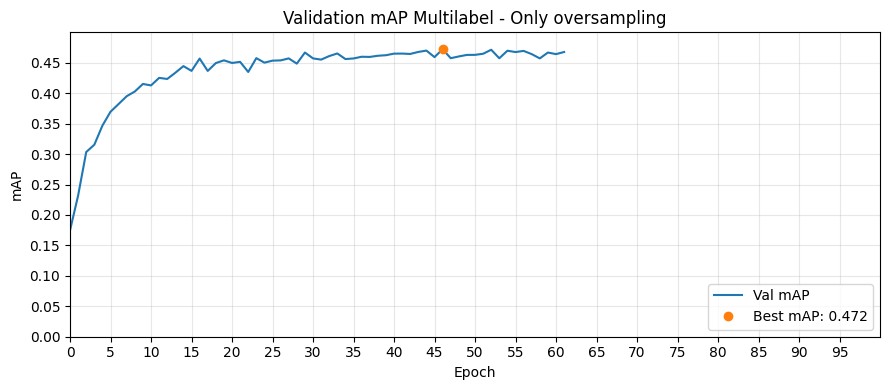

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(9, 4))

axs.plot(val_mAP_model_9, label= "Val mAP")
axs.plot(val_mAP_model_9.idxmax(), val_mAP_model_9.max(), "o", label=f"Best mAP: {val_mAP_model_9.max():.3f}")
axs.set_title("Validation mAP comparison - Multilabel CNN")
axs.set_xlabel("Epoch")
axs.set_ylabel("mAP")
axs.set_ylim(0, 0.5)
axs.set_xlim(0, 100)
axs.set_yticks(np.arange(0, 0.50, 0.05))
axs.set_xticks(np.arange(0, 100, 5))
axs.grid(alpha=0.3)
axs.legend(loc="lower right")

plt.tight_layout()
plt.show()

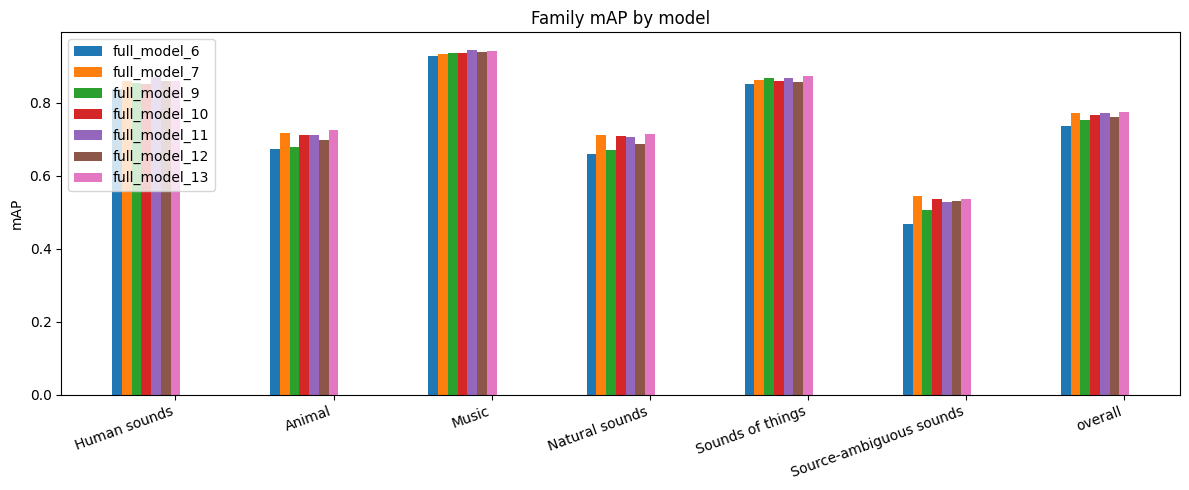

In [6]:
family_models = load_training_log("output_logs_and_models/family_mAP_log.csv")
model_names   = list(family_models.keys())

# Get families from first model
families = family_models[model_names[0]]["history"]["family"].tolist()

x      = np.arange(len(families))
width  = 0.8 / len(model_names)  # bar width scales with number of models

fig, ax = plt.subplots(figsize=(12, 5))

for i, name in enumerate(list(model_names)[6:]):
    df   = family_models[name]["history"].set_index("family")
    mAPs = [df.loc[f, "mAP"] for f in families]
    ax.bar(x + i * width - 0.4 + width/2, mAPs, width, label=name)

ax.set_xticks(x)
ax.set_xticklabels(families, rotation=20, ha="right")
ax.set_ylabel("mAP")
ax.set_title("Family mAP by model")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [7]:
#list of models in order of best to worst mAP
model_mAPs = {name: max(model["history"]["val_mAP"]) for name, model in list(models.items())[6:]}
model_mAPs = dict(sorted(model_mAPs.items(), key=lambda item: item[1], reverse=True))
print("Model mAPs in order of best to worst:")
for name, mAP in model_mAPs.items():
    print(f"{name}: {mAP:.3f}")

Model mAPs in order of best to worst:
full_model_13: 0.499
full_model_11: 0.490
full_model_10: 0.474
full_model_12: 0.473
full_model_9: 0.472
full_model_7: 0.471


In [8]:
def load_results_summary():
    training  = load_training_log("output_logs_and_models/training_log.csv")
    families  = load_training_log("output_logs_and_models/family_mAP_log.csv")
    metrics   = load_training_log("output_logs_and_models/metrics_log.csv")

    rows = []
    for name in training.keys():
        # Best epoch and val mAP from training log
        hist        = training[name]["history"]
        best_idx    = hist["val_mAP"].idxmax()
        best_epoch  = hist.loc[best_idx, "epoch"]
        best_mAP    = hist.loc[best_idx, "val_mAP"]

        # Overall family mAP
        fam_mAP = None
        if name in families:
            df_fam  = families[name]["history"].set_index("family")
            fam_mAP = df_fam.loc["overall", "mAP"] if "overall" in df_fam.index else None

        # d' and lwlrap
        dprime, lwlrap = None, None
        if name in metrics:
            df_met = metrics[name]["history"].set_index("metric")
            dprime  = df_met.loc["d_prime", "value"] if "d_prime" in df_met.index else None
            lwlrap  = df_met.loc["lwlrap",  "value"] if "lwlrap"  in df_met.index else None

        rows.append({
            "model":          name,
            "best_epoch":     best_epoch,
            "val_mAP":        best_mAP,
            "family_mAP":     fam_mAP,
            "d_prime":        dprime,
            "lwlrap":         lwlrap,
        })

    df = pd.DataFrame(rows).sort_values("val_mAP", ascending=False).reset_index(drop=True)
    return df

df_summary = load_results_summary()
print(df_summary.to_string())

            model  best_epoch  val_mAP  family_mAP  d_prime  lwlrap
0   full_model_13          86   0.4990      0.7750   2.5779  0.7078
1   full_model_11          91   0.4899      0.7714   2.5694  0.7093
2   full_model_10          82   0.4741      0.7671   2.5690  0.6992
3   full_model_12          45   0.4734      0.7613   2.5361  0.7031
4    full_model_9          47   0.4723      0.7518   2.4736  0.6915
5    full_model_7          75   0.4712      0.7708   2.5262  0.6993
6    full_model_6          30   0.4311      0.7356   2.4235  0.6788
7    full_model_2          93   0.4046      0.6988   2.3540  0.6727
8    full_model_3          87   0.3872      0.6784   2.3146  0.6521
9    full_model_0          46   0.3817      0.6998   2.3806  0.6617
10   full_model_1          90   0.3813      0.7036   2.4550  0.6585
11   full_model_4          88   0.3773      0.6793   2.3143  0.6539


In [9]:
df_summary = load_results_summary()

# Keep only specific models and rename them
name_map = {
    "full_model_9":  "Only oversampling",
    "full_model_11": "With focal loss + bias init",
    "full_model_12": "Baseline",
    "full_model_13": "Oversampling + Spec aug + Mixup aug"
}

df_summary = df_summary[df_summary["model"].isin(name_map.keys())].copy()
df_summary["model"] = df_summary["model"].map(name_map)

#display summary table as dataframe
display(df_summary)

,model,best_epoch,val_mAP,family_mAP,d_prime,lwlrap
0,Oversampling + Spec aug + Mixup aug,86,0.4990,0.7750,2.5779,0.7078
1,With focal loss + bias init,91,0.4899,0.7714,2.5694,0.7093
3,Baseline,45,0.4734,0.7613,2.5361,0.7031
4,Only oversampling,47,0.4723,0.7518,2.4736,0.6915


full_model_7: with oversampling, no spec augment, no focal loss, bias initialization
full_model_9: with oversampling, no spec augment, no focal loss, no bias initialization
full_model_10: no oversampling, no spec augment, with focal loss, with bias initialization
full_model_11: with oversampling, with spec augment, no focal loss, no bias initialization
full_model_12: no oversampling, no spec augment, no focal loss, no bias initialization